In [1]:
from matplotlib.lines import lineStyles

CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"
BASE_CONFIG = {
    "vocab_size": 50257,
    "context_length": 1024,
    "drop_rate": 0.0,
    "qkv_bias": True
}
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12}
}
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

In [2]:
import os, sys
sys.path.append(os.pardir)

In [3]:
from chapter5.gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

In [4]:
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")
model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [5]:
from previous_chapters import generate_text_simple, text_to_token_ids, token_ids_to_text
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

In [6]:
text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [7]:
for param in model.parameters():
    param.requires_grad = False

In [8]:
import torch

In [9]:
torch.manual_seed(123)
num_classes = 2
model.out_head = torch.nn.Linear(
    in_features=BASE_CONFIG["emb_dim"],
    out_features=num_classes,
)

In [10]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

In [11]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)

In [12]:
with torch.no_grad():
    outputs = model(inputs)
print("output: ", outputs)
print("output dimensions: ", outputs.shape)

output:  tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
output dimensions:  torch.Size([1, 4, 2])


In [13]:
print("last output token: ", outputs[:, -1, :])

last output token:  tensor([[-3.5983,  3.9902]])


In [14]:
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas)
print("label: ", label)

label:  tensor(1)


In [15]:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("label: ", label.item())

label:  1


In [16]:
from dataset import SpamDataset

train_dataset = SpamDataset(
    csv_file="train.csv", max_length=None, tokenizer=tokenizer
)
val_dataset = SpamDataset(
    csv_file="validation.csv", max_length=train_dataset.max_length, tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv", max_length=train_dataset.max_length, tokenizer=tokenizer
)
num_workers = 0
batch_size = 8
from torch.utils.data import DataLoader
train_loader = DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, drop_last=True
)
val_loader = DataLoader(
    dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False
)
test_loader = DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, drop_last=False
)

In [17]:
from gpt_finetune import calc_accuracy_loader, calc_loss_loader

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

torch.manual_seed(123)

In [19]:
train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

In [20]:
print(f"train accuracy: {train_accuracy:.4f} | val accuracy: {val_accuracy:.4f} | test accuracy: {test_accuracy:.4f}")

train accuracy: 0.4625 | val accuracy: 0.4500 | test accuracy: 0.4875


In [21]:
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

In [22]:
print(f" train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | test loss: {test_loss:.4f}")

 train loss: 2.4529 | val loss: 2.5830 | test loss: 2.3220


In [23]:
import time
start_time = time.time()

torch.manual_seed(123)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

In [24]:
from gpt_finetune import train_classifier_simple

In [25]:
train_losses, val_losses, train_accs, val_accs, example_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs, eval_freq=50, eval_iter=10
)

Epoch 0, Step 0, Train Loss: 2.5594, Val Loss: 2.6258
Epoch 0, Step 50, Train Loss: 0.6279, Val Loss: 0.6411
Epoch 0, Step 100, Train Loss: 0.5722, Val Loss: 0.5702
Epoch 0, Train Accuracy: 0.7212, Val Accuracy: 0.7315
Epoch 1, Step 150, Train Loss: 0.5168, Val Loss: 0.4724
Epoch 1, Step 200, Train Loss: 0.3968, Val Loss: 0.4123
Epoch 1, Step 250, Train Loss: 0.4308, Val Loss: 0.3685
Epoch 1, Train Accuracy: 0.8462, Val Accuracy: 0.8523
Epoch 2, Step 300, Train Loss: 0.2857, Val Loss: 0.3295
Epoch 2, Step 350, Train Loss: 0.3302, Val Loss: 0.3120
Epoch 2, Train Accuracy: 0.8721, Val Accuracy: 0.9128
Epoch 3, Step 400, Train Loss: 0.2113, Val Loss: 0.1951
Epoch 3, Step 450, Train Loss: 0.1786, Val Loss: 0.1184
Epoch 3, Step 500, Train Loss: 0.1622, Val Loss: 0.1190
Epoch 3, Train Accuracy: 0.9490, Val Accuracy: 0.9530
Epoch 4, Step 550, Train Loss: 0.2263, Val Loss: 0.1066
Epoch 4, Step 600, Train Loss: 0.0676, Val Loss: 0.0456
Epoch 4, Train Accuracy: 0.9721, Val Accuracy: 0.9732


In [26]:
end_time = time.time()
excution_time_minutes = (end_time-start_time) /60
print(f"Training time: {excution_time_minutes:.2f} minutes")

Training time: 23.40 minutes


In [27]:
import matplotlib.pyplot as plt

def plot_values(
        epochs_seen, examples_seen, train_values, val_values, label="loss"
):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_values, label="train")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")

    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(examples_seen, train_values, alpha=0)
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()
    plt.show()


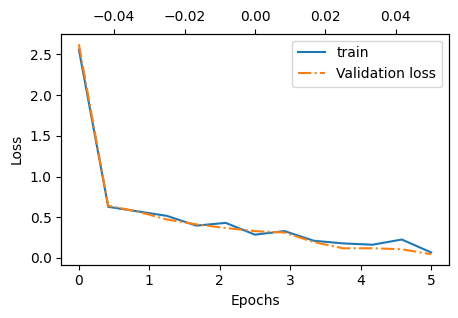

In [28]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, example_seen, len(train_losses))
plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

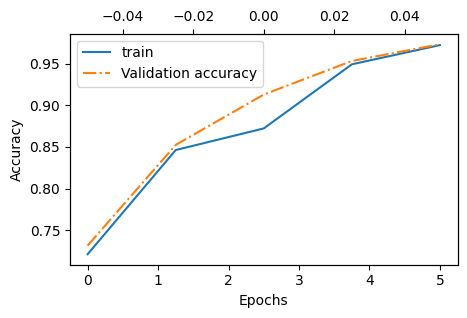

In [29]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, example_seen, len(train_accs))
plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [30]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
print(f"Train accuracy: {train_accuracy:.4f}")
val_accuracy = calc_accuracy_loader(val_loader, model, device)
print(f"Val accuracy: {val_accuracy:.4f}")
test_accuracy = calc_accuracy_loader(test_loader, model, device)
print(f"Test accuracy: {test_accuracy:.4f}")

Train accuracy: 0.9721
Val accuracy: 0.9732
Test accuracy: 0.9567


In [31]:
torch.save(model.state_dict(), "gpt2_spam_model.pth")